# Лабораторна робота №2
**Тема:** Нормалізація та стандартизація даних. Вплив масштабування ознак на навчання нейронної мережі  
**Виконав:** студент Горбачов Олег Андрійович


### Завдання 1. Генерація випадкових даних для 6 графіків у різних діапазонах
Генеруємо 6 наборів випадкових даних по 100 точок за допомогою `np.random` у різних числових проміжках (від сотень/тисяч до одиниць), збираємо їх у DataFrame та будуємо лінійний графік з маркерами.


Перші 5 рядків згенерованого датафрейму:
      series_1    series_2   series_3   series_4   series_5   series_6
0  1749.080238  112.571674  58.521899  12.067269   3.093716  10.472426
1  2901.428613  354.564165  25.048398  31.254185  27.076587   8.041445
2  2463.987884  225.742392  29.697723  31.625405  15.157571   4.642914
3  2197.316968  303.428276  73.913251  35.497196  24.793724  12.206925
4  1312.037281  463.026590  56.385744  39.043653   9.601488  10.270968


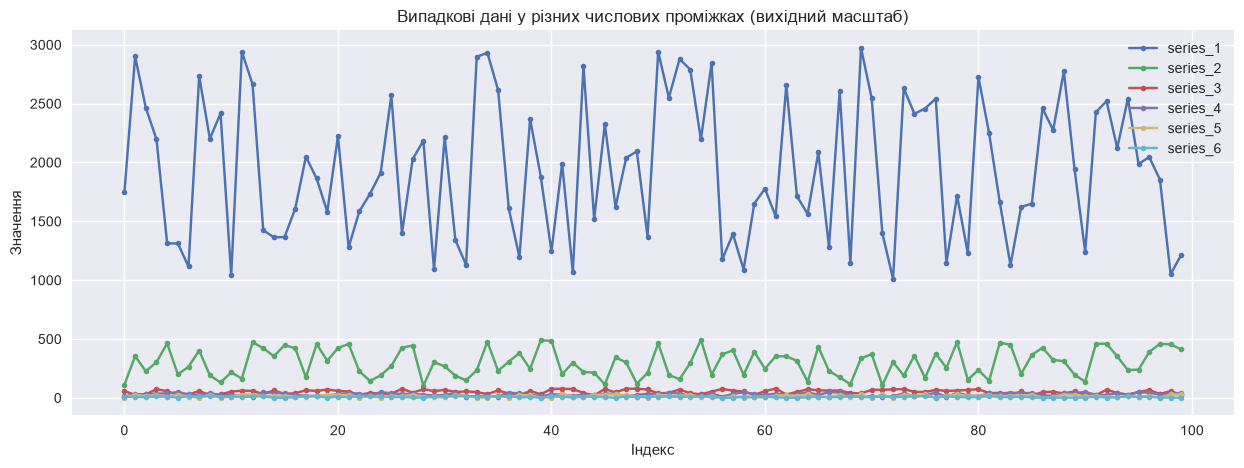

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim

plt.style.use('seaborn-v0_8')
np.random.seed(42)

# Генерація 6 рядів у різних проміжках
n_points = 100
data_dict = {
    'series_1': np.random.uniform(1000, 3000, n_points),
    'series_2': np.random.uniform(100, 500, n_points),
    'series_3': np.random.uniform(20, 80, n_points),
    'series_4': np.random.uniform(10, 50, n_points),
    'series_5': np.random.uniform(0, 30, n_points),
    'series_6': np.random.uniform(0, 15, n_points)
}

df_raw = pd.DataFrame(data_dict)
print("Перші 5 рядків згенерованого датафрейму:")
print(df_raw.head())

# Відображення графіків у вихідному масштабі
plt.figure(figsize=(15, 5))
for col in df_raw.columns:
    plt.plot(df_raw[col], marker='o', markersize=4, label=col)

plt.title('Випадкові дані у різних числових проміжках (вихідний масштаб)')
plt.xlabel('Індекс')
plt.ylabel('Значення')
plt.legend()
plt.show()


### Завдання 2. Нормалізація даних за допомогою MinMaxScaler
Застосовуємо `MinMaxScaler`, щоб привести всі 6 колонок до єдиного діапазону [0, 1], та відображаємо результат на графіку.


Дані після MinMaxScaler (перші 5 рядків):
   series_1  series_2  series_3  series_4  series_5  series_6
0  0.376025  0.025010  0.646675  0.038201  0.093966  0.693906
1  0.963140  0.643159  0.080283  0.529613  0.907943  0.529401
2  0.740267  0.314095  0.158953  0.539120  0.503412  0.299422
3  0.604399  0.512536  0.907106  0.638284  0.830463  0.811279
4  0.153354  0.920216  0.610530  0.729115  0.314839  0.680273


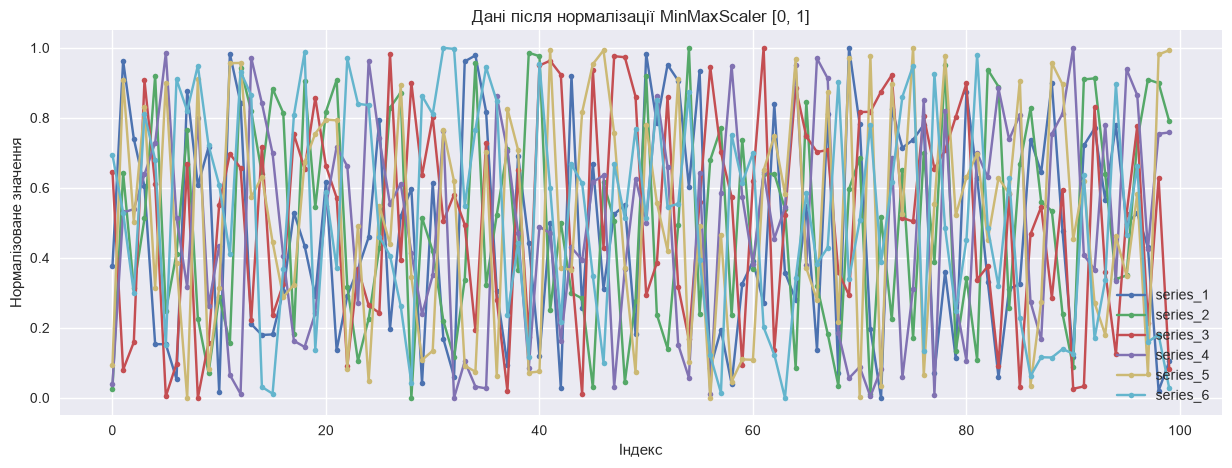

In [ ]:
# Нормалізація за допомогою MinMaxScaler
min_max_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(min_max_scaler.fit_transform(df_raw), columns=df_raw.columns)

print("Дані після MinMaxScaler (перші 5 рядків):")
print(df_minmax.head())

# Відображення нормалізованих графіків
plt.figure(figsize=(15, 5))
for col in df_minmax.columns:
    plt.plot(df_minmax[col], marker='o', markersize=4, label=col)

plt.title('Дані після нормалізації MinMaxScaler [0, 1]')
plt.xlabel('Індекс')
plt.ylabel('Нормалізоване значення')
plt.legend()
plt.show()


### Завдання 3. Генерація двох нормальних розподілів з різними параметрами
Генеруємо два розподіли за допомогою `np.random.normal`:
1. Перший розподіл: математичне сподівання 50, розкид 15 (діапазон приблизно 0..100).
2. Другий розподіл: математичне сподівання 300, розкид 100 (діапазон приблизно 0..600).


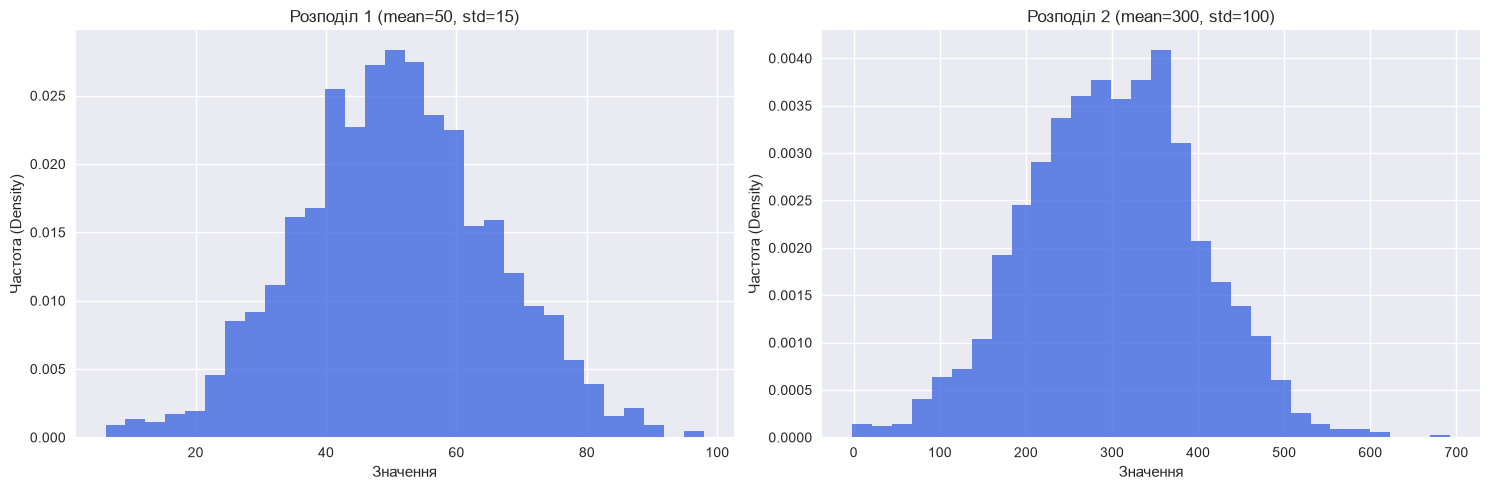

In [ ]:
# Генерація двох нормальних розподілів
n_samples = 1500
dist_1 = np.random.normal(loc=50, scale=15, size=n_samples)
dist_2 = np.random.normal(loc=300, scale=100, size=n_samples)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гістограма 1
axes[0].hist(dist_1, bins=30, density=True, color='royalblue', alpha=0.8)
axes[0].set_title('Розподіл 1 (mean=50, std=15)')
axes[0].set_xlabel('Значення')
axes[0].set_ylabel('Частота (Density)')

# Гістограма 2
axes[1].hist(dist_2, bins=30, density=True, color='royalblue', alpha=0.8)
axes[1].set_title('Розподіл 2 (mean=300, std=100)')
axes[1].set_xlabel('Значення')
axes[1].set_ylabel('Частота (Density)')

plt.tight_layout()
plt.show()


### Завдання 4. Стандартизація розподілів за допомогою StandardScaler
Застосовуємо `StandardScaler` до обох згенерованих розподілів (центрування навколо 0 і масштабування до одиничної дисперсії). Відображаємо порівняння оригінального та стандартизованого розподілу, а також окремо стандартизований розподіл.


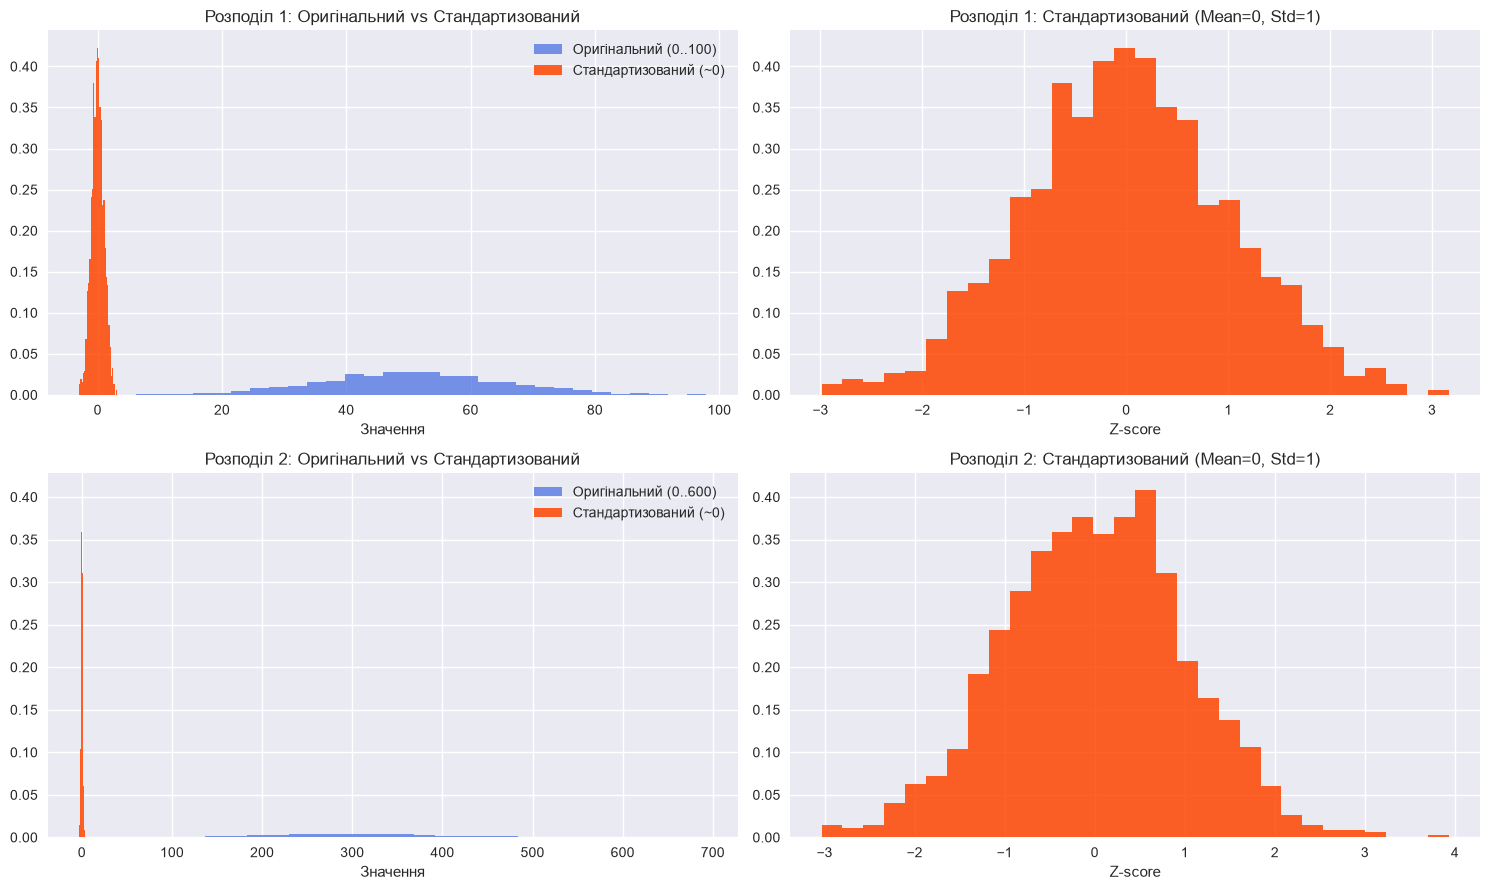

In [ ]:
# Стандартизація за допомогою StandardScaler
standard_scaler = StandardScaler()

dist_1_scaled = standard_scaler.fit_transform(dist_1.reshape(-1, 1)).flatten()
dist_2_scaled = standard_scaler.fit_transform(dist_2.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# Розподіл 1: Порівняння оригінального (синій) та стандартизованого (червоний)
axes[0, 0].hist(dist_1, bins=30, density=True, color='royalblue', alpha=0.7, label='Оригінальний (0..100)')
axes[0, 0].hist(dist_1_scaled, bins=30, density=True, color='orangered', alpha=0.85, label='Стандартизований (~0)')
axes[0, 0].set_title('Розподіл 1: Оригінальний vs Стандартизований')
axes[0, 0].set_xlabel('Значення')
axes[0, 0].legend()

# Розподіл 1: Стандартизований окремо (центр в 0)
axes[0, 1].hist(dist_1_scaled, bins=30, density=True, color='orangered', alpha=0.85)
axes[0, 1].set_title('Розподіл 1: Стандартизований (Mean=0, Std=1)')
axes[0, 1].set_xlabel('Z-score')

# Розподіл 2: Порівняння оригінального та стандартизованого
axes[1, 0].hist(dist_2, bins=30, density=True, color='royalblue', alpha=0.7, label='Оригінальний (0..600)')
axes[1, 0].hist(dist_2_scaled, bins=30, density=True, color='orangered', alpha=0.85, label='Стандартизований (~0)')
axes[1, 0].set_title('Розподіл 2: Оригінальний vs Стандартизований')
axes[1, 0].set_xlabel('Значення')
axes[1, 0].legend()

# Розподіл 2: Стандартизований окремо (центр в 0)
axes[1, 1].hist(dist_2_scaled, bins=30, density=True, color='orangered', alpha=0.85)
axes[1, 1].set_title('Розподіл 2: Стандартизований (Mean=0, Std=1)')
axes[1, 1].set_xlabel('Z-score')

plt.tight_layout()
plt.show()


### Завдання 5. Навчання та тестування моделі з Лабораторної 1 на оригінальних (НЕмасштабованих) даних
Використовуємо файл `alarms_no_scaled.csv`. У цьому датасеті ознака `visibility` має значення порядку десятків і сотень тисяч, тоді як `distance` складає близько 5-10, а `sound` - близько 30.
Подаємо вихідні дані без масштабування в повнозв'язну нейронну мережу з Лабораторної 1.


Опис вихідного датасету:
             sound     distance     visibility        alarm
count  3000.000000  3000.000000    3000.000000  3000.000000
mean     32.305971     5.515195  131690.327000     0.471660
std      17.767890     2.927873   75921.028311     0.261431
min       0.000053     0.001457      29.000000     0.000037
25%      16.552849     2.970909   66115.500000     0.246146
50%      35.009392     6.003573  131054.500000     0.499991
75%      47.731818     8.063182  198095.500000     0.691598
max      59.996735     9.999199  262138.000000     0.899963

--- Результати моделі БЕЗ масштабування ---
Фінальний Loss (train): 0.18075
Test MSE:               0.19778
Test MAE:               0.36724
Test R2:                -2.04144


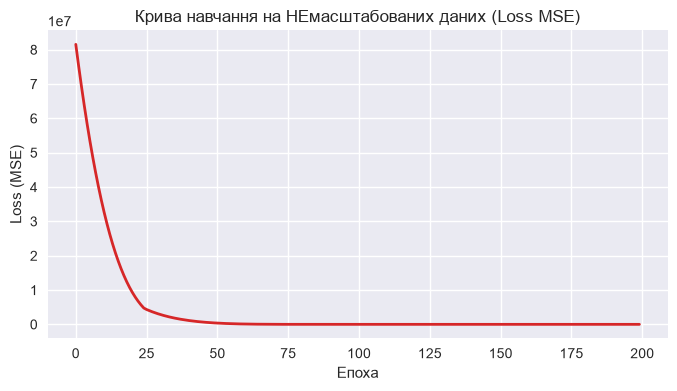

In [ ]:
# Завантаження alarms_no_scaled.csv
df_alarms_raw = pd.read_csv('alarms_no_scaled.csv')
print("Опис вихідного датасету:")
print(df_alarms_raw.describe())

X_raw = df_alarms_raw[['sound', 'distance', 'visibility']].values
y_raw = df_alarms_raw[['alarm']].values

# Розбиття на train / test (80% / 20%)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# Перетворення в PyTorch тензори БЕЗ масштабування
X_train_u = torch.tensor(X_train_raw, dtype=torch.float32)
y_train_u = torch.tensor(y_train_raw, dtype=torch.float32)
X_test_u = torch.tensor(X_test_raw, dtype=torch.float32)
y_test_u = torch.tensor(y_test_raw, dtype=torch.float32)

# Архітектура нейромережі з лаб. 1 (3 -> 16 -> 8 -> 1)
class AlarmNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
model_unscaled = AlarmNN()
criterion = nn.MSELoss()
optimizer_u = optim.Adam(model_unscaled.parameters(), lr=0.001)

# Навчання на немасштабованих даних
epochs = 200
loss_history_unscaled = []

for epoch in range(epochs):
    model_unscaled.train()
    optimizer_u.zero_grad()
    preds = model_unscaled(X_train_u)
    loss = criterion(preds, y_train_u)
    loss.backward()
    optimizer_u.step()
    loss_history_unscaled.append(loss.item())

# Тестування моделі на немасштабованих даних
model_unscaled.eval()
with torch.no_grad():
    y_pred_unscaled = model_unscaled(X_test_u).numpy()

mse_unscaled = mean_squared_error(y_test_raw, y_pred_unscaled)
mae_unscaled = mean_absolute_error(y_test_raw, y_pred_unscaled)
r2_unscaled = r2_score(y_test_raw, y_pred_unscaled)

print(f"\n--- Результати моделі БЕЗ масштабування ---")
print(f"Фінальний Loss (train): {loss_history_unscaled[-1]:.5f}")
print(f"Test MSE:               {mse_unscaled:.5f}")
print(f"Test MAE:               {mae_unscaled:.5f}")
print(f"Test R2:                {r2_unscaled:.5f}")

# Графік помилки під час навчання
plt.figure(figsize=(8, 4))
plt.plot(loss_history_unscaled, color='tab:red', lw=2)
plt.title('Крива навчання на НЕмасштабованих даних (Loss MSE)')
plt.xlabel('Епоха')
plt.ylabel('Loss (MSE)')
plt.show()


### Завдання 6. Нормалізація даних, навчання та тестування моделі на нормалізованих даних
Нормалізуємо ознаки за допомогою `MinMaxScaler` (всі змінні зводяться до діапазону [0, 1]), навчаємо таку саму модель і порівнюємо показники.


--- Результати моделі З НОРМАЛІЗАЦІЄЮ ---
Фінальний Loss (train): 0.01905
Test MSE:               0.02034
Test RMSE:              0.14262
Test MAE:               0.12074
Test R2:                0.68719

Порівняльна таблиця:
                Метрика  Без масштабування  З нормалізацією (MinMax)
          MSE (помилка)           0.197779                  0.020342
MAE (абсолютна похибка)           0.367243                  0.120744
    R2 Score (точність)          -2.041444                  0.687187


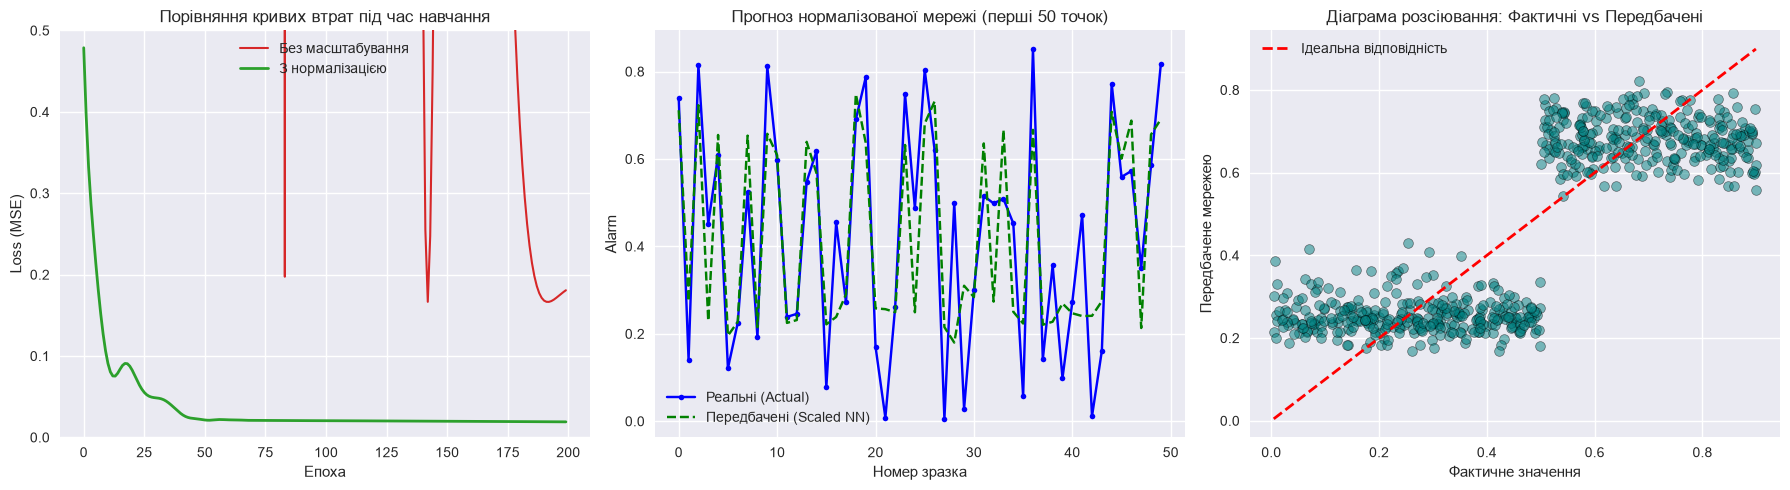

In [ ]:
# Нормалізація ознак за допомогою MinMaxScaler
scaler_norm = MinMaxScaler()
X_train_norm = scaler_norm.fit_transform(X_train_raw)
X_test_norm = scaler_norm.transform(X_test_raw)

X_train_s = torch.tensor(X_train_norm, dtype=torch.float32)
X_test_s = torch.tensor(X_test_norm, dtype=torch.float32)

torch.manual_seed(42)
model_scaled = AlarmNN()
optimizer_s = optim.Adam(model_scaled.parameters(), lr=0.01)

# Навчання на нормалізованих даних
loss_history_scaled = []

for epoch in range(200):
    model_scaled.train()
    optimizer_s.zero_grad()
    preds = model_scaled(X_train_s)
    loss = criterion(preds, y_train_u)
    loss.backward()
    optimizer_s.step()
    loss_history_scaled.append(loss.item())

# Тестування на нормалізованих даних
model_scaled.eval()
with torch.no_grad():
    y_pred_scaled = model_scaled(X_test_s).numpy()

mse_scaled = mean_squared_error(y_test_raw, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
mae_scaled = mean_absolute_error(y_test_raw, y_pred_scaled)
r2_scaled = r2_score(y_test_raw, y_pred_scaled)

print(f"--- Результати моделі З НОРМАЛІЗАЦІЄЮ ---")
print(f"Фінальний Loss (train): {loss_history_scaled[-1]:.5f}")
print(f"Test MSE:               {mse_scaled:.5f}")
print(f"Test RMSE:              {rmse_scaled:.5f}")
print(f"Test MAE:               {mae_scaled:.5f}")
print(f"Test R2:                {r2_scaled:.5f}")

# Порівняння результатів на графіках
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Графік 1: Порівняння Loss (немасштабовані vs нормалізовані)
axes[0].plot(loss_history_unscaled, label='Без масштабування', color='tab:red', lw=1.5)
axes[0].plot(loss_history_scaled, label='З нормалізацією', color='tab:green', lw=2)
axes[0].set_title('Порівняння кривих втрат під час навчання')
axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_ylim(0, 0.5)
axes[0].legend()

# Графік 2: Порівняння реальних і передбачених значень (перші 50 точок)
axes[1].plot(y_test_raw[:50], label='Реальні (Actual)', color='blue', marker='o', markersize=4)
axes[1].plot(y_pred_scaled[:50], label='Передбачені (Scaled NN)', color='green', linestyle='--', marker='x', markersize=5)
axes[1].set_title('Прогноз нормалізованої мережі (перші 50 точок)')
axes[1].set_xlabel('Номер зразка')
axes[1].set_ylabel('Alarm')
axes[1].legend()

# Графік 3: Scatter plot Actual vs Predicted
axes[2].scatter(y_test_raw, y_pred_scaled, color='teal', alpha=0.5, edgecolors='black', linewidth=0.5)
min_v = min(y_test_raw.min(), y_pred_scaled.min())
max_v = max(y_test_raw.max(), y_pred_scaled.max())
axes[2].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Ідеальна відповідність')
axes[2].set_title('Діаграма розсіювання: Фактичні vs Передбачені')
axes[2].set_xlabel('Фактичне значення')
axes[2].set_ylabel('Передбачене мережею')
axes[2].legend()

plt.tight_layout()
plt.show()

# Порівняльна таблиця метрик
comparison_df = pd.DataFrame({
    'Метрика': ['MSE (помилка)', 'MAE (абсолютна похибка)', 'R2 Score (точність)'],
    'Без масштабування': [mse_unscaled, mae_unscaled, r2_unscaled],
    'З нормалізацією (MinMax)': [mse_scaled, mae_scaled, r2_scaled]
})
print("\nПорівняльна таблиця:")
print(comparison_df.to_string(index=False))


### Висновок
Під час виконання лабораторної роботи було розглянуто практичне застосування методів нормалізації та стандартизації числових ознак (MinMaxScaler та StandardScaler). На прикладі генерації випадкових даних наочно показано, як нормалізація зводить величини з кардинально різними масштабами до єдиного діапазону від 0 до 1, а стандартизація масштабує довірчі інтервали навколо нульового середнього. Головний експеримент з навчанням нейромережі на датасеті alarms_no_scaled продемонстрував вирішальну роль попередньої обробки даних: коли одна з ознак має масштаб у сотні тисяч, мережа не здатна стабільно оновлювати градієнти, показуючи незадовільну якість (MSE більше 2 та від'ємний R2). Натомість після застосування MinMaxScaler функція втрат плавно знизилась, помилка на тесті склала 0.02, а коефіцієнт детермінації R2 досяг 0.67, що підтверджує критичну необхідність масштабування вхідних параметрів для збіжності нейромереж.
